# R19-H199 - Sealing the coverage-ceiling flip: the router-instrumented wide census

First-class, router-primary census of the wide-101 probe set ([`probes-wide-h188.json`](../data/processed/probes-wide-h188.json))
at **k=64** against **neo4j2** (READ-ONLY). The presence scorer is the **H194 GPU-free router** as PRIMARY:
the deterministic value comparator for numeric/dimension golds + word-overlap for prose/feature golds
(reused verbatim from `instrument_bench_h194.ipynb`). Retrieval queries the HNSW index at **top_k=128** and
truncates to the evaluation k=64 (H195 convention - never query at exactly the evaluation k).

Every miss is classified into {absent-from-graph, present-but-unranked}; the pre-H194 never-entailing class
should **dissolve** under the router (the key-family comparator credits key-encoded value carriers). The three
registered clauses:

- **(a)** reproduce the H193 delta estimate within 3 golds per class (absent >= 70%, fidelity-class overlap >= 60%)
- **(b)** forensics on the 3 previously-unmapped absents ('4 L/min', Weinmann WM31660, WM93335) - trace the value
  from the source PDF through the parser output to the graph
- **(c)** the present-but-unranked golds - measure each carrier's full-corpus query-similarity rank and whether its
  embedding text is diluted by long appended descriptions (H184 signature)


In [1]:
import os, re, json, math, pickle, hashlib, itertools, unicodedata, datetime
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from rich import print as rprint
from rich.progress import Progress

from knowledge_graph_foundry import load_settings, Foundry
from knowledge_graph_foundry.graph.graphrag import vector_query


2026-07-07 17:30:36.979 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


In [2]:
# ---- config (neo4j2 READ-ONLY) ----
ROOT = Path("..")
BASE_URI = "bolt://user-konrad.jelen-kgf-neo4j2:7687"       # neo4j2 baseline, READ-ONLY
settings = load_settings(ROOT / "config.yml")
VEC = settings.graphrag.vector_index_name
K64 = 64                                                    # evaluation k
RETRIEVE_TOPK = 128                                         # HNSW headroom, truncated to k=64 (H195 convention)
REL_LIMIT = 15
np.random.seed(42)
rprint(f"[cyan]config[/cyan] uri=neo4j2 vec={VEC} eval_k={K64} retrieve_top_k={RETRIEVE_TOPK} rel_cap={REL_LIMIT}")


config uri=neo4j2 vec=kgf_entity_embeddings eval_k=64 retrieve_top_k=128 rel_cap=15

In [3]:
# ---- graph pull (READ-ONLY) + render primitives (reused from instrument_bench_h194) ----
d = GraphDatabase.driver(BASE_URI, auth=("neo4j", "kgfoundry"))
with d.session() as s:
    ents = s.run("MATCH (e:Entity) RETURN e.id AS id, e.name AS name, e.description AS description, "
                 "properties(e) AS props, labels(e) AS types, e.embedding AS emb").data()
    edges = s.run("MATCH (a:Entity)-[r]-(b:Entity) WHERE type(r)<>'SIMILAR_TO' AND a.id<b.id "
                  "RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel").data()
    prop_rows = s.run("MATCH (p:Proposition)-[:ABOUT]->(e:Entity) RETURN e.id AS eid, p.text AS text").data()
    alias_rows = s.run("MATCH (e:Entity)-[:SAME_AS*1..2]-(a:Entity) WHERE e.id<>a.id "
                       "RETURN e.id AS eid, collect(DISTINCT a.id)[..5] AS aliases").data()
d.close()
node = {r["id"]: r for r in ents}; names = {r["id"]: r["name"] for r in ents}
props_by = defaultdict(list); [props_by[r["eid"]].append(r["text"]) for r in prop_rows]
alias_by = {r["eid"]: r["aliases"] for r in alias_rows}
rels_by = defaultdict(list)
for e in edges:
    rels_by[e["a"]].append((e["rel"], e["b"])); rels_by[e["b"]].append((e["rel"], e["a"]))
def spec_of(r): return {k.removeprefix("prop_"): v for k, v in r["props"].items() if k.startswith("prop_")}
def merged_spec(nid):
    r = node[nid]; spec = dict(spec_of(r))
    for a in [a for a in alias_by.get(nid, []) if a in node]:
        for k, v in spec_of(node[a]).items(): spec.setdefault(k, v)
    return spec
def base_render(nid):
    r = node[nid]; spec = merged_spec(nid); al = [a for a in alias_by.get(nid, []) if a in node]
    aka = (f"Also known as: {', '.join(names.get(a, '') for a in al)}\n" if al else "")
    return f"## {r['name']} ({', '.join(r['types'])})\n{aka}{r['description'] or ''}\nProperties: {json.dumps(spec, default=str)}"
def seed_render(nid): return base_render(nid) + " " + " ; ".join(f"{t} -> {names.get(b,'')}" for t, b in rels_by.get(nid, [])[:REL_LIMIT])
def units_of(ids): return [seed_render(n) for n in ids] + [t for n in ids for t in props_by.get(n, [])]

# entity embedding matrix (normalized) for full-corpus cosine ranking in clause (c)
EIDS = [r["id"] for r in ents if r["emb"] is not None]
EMB = np.array([node[i]["emb"] for i in EIDS], dtype=np.float32)
EMB /= (np.linalg.norm(EMB, axis=1, keepdims=True) + 1e-9)
EIDX = {i: k for k, i in enumerate(EIDS)}
rprint(f"[green]pulled[/green] entities {len(node)} edges {len(edges)} propositions {len(prop_rows)} "
       f"emb-matrix {EMB.shape}")


pulled entities 2798 edges 3905 propositions 19654 emb-matrix (2798, 1024)

In [4]:
# ---- DETERMINISTIC VALUE COMPARATOR + word-overlap (reused VERBATIM from instrument_bench_h194) ----
_TM = dict.fromkeys(map(ord, "®™©"), None)
def gnorm(s):
    s = (s or "").translate(_TM); s = unicodedata.normalize("NFKC", s)
    s = s.replace(" ", " ").replace("×", "x").replace("*", "x").replace("·", "x")
    s = re.sub(r"(?<=\d),(?=\d)", "", s)
    return re.sub(r"\s+", " ", s.casefold()).strip()
def _norm(s): return re.sub(r"\s+", " ", (s or "").casefold())
UNITWORD = {"mm":"len_mm","cm":"len_cm","g":"mass_g","kg":"mass_kg","oz":"mass_oz","ml":"vol_ml","l":"vol_l",
   "db":"sound_db","dba":"sound_db","w":"power_w","hz":"freq_hz","cmh2o":"press","m":"alt_m",
   "min":"time_min","mins":"time_min","minute":"time_min","minutes":"time_min","year":"warr_y","years":"warr_y"}
FAM_EQ = {"len_mm":{"len_mm"},"len_cm":{"len_cm"},"alt_m":{"alt_m"},"mass_g":{"mass_g"},"mass_kg":{"mass_kg"},
   "mass_oz":{"mass_oz"},"vol_ml":{"vol_ml","vol_l"},"sound_db":{"sound_db"},"power_w":{"power_w"},
   "time_min":{"time_min"},"warr_y":{"warr_y"},"press":{"press"},"freq_hz":{"freq_hz"}}
def key_family(k):
    k = k.lower()
    if "dimension" in k or re.search(r"_mm\b", k) or "length_mm" in k: return "len_mm"
    if "altitude" in k: return "alt_m"
    if k.endswith("_kg") or "weight_kg" in k: return "mass_kg"
    if re.search(r"_g\b", k): return "mass_g"
    if "_oz" in k: return "mass_oz"
    if re.search(r"_ml\b", k) or "capacity_ml" in k or "water" in k: return "vol_ml"
    if "sound" in k or re.search(r"_db\b", k) or "noise" in k: return "sound_db"
    if "power" in k or "consumption" in k: return "power_w"
    if "ramp" in k or "delay" in k: return "time_min"
    if "warranty" in k: return "warr_y"
    if "pressure" in k: return "press"
    return None
def nums_in(v): return re.findall(r"\d+(?:\.\d+)?", str(v).replace(",", ""))
def ctx_quantities(ids):
    Q = set()
    for nid in ids:
        spec = merged_spec(nid); unit_for = {}
        for k, v in spec.items():
            if k.endswith("_unit"):
                fam = UNITWORD.get(gnorm(str(v)).replace(" ", ""))
                if fam: unit_for[k[:-5]] = fam
        for k, v in spec.items():
            fam = key_family(k) or unit_for.get(k)
            if fam:
                for n in nums_in(v): Q.add((n, fam))
        text = gnorm(seed_render(nid) + " " + " ".join(props_by.get(nid, [])))
        for m in re.finditer(r"(\d+(?:\.\d+)?)\s*(mm|cm|dba|db\(a\)|db|kg|oz|ml|cmh2o|hz|mins|minutes|minute|min|years|year|w|g|l|m)\b", text):
            fam = UNITWORD.get(m.group(2).replace("(a)", ""))
            if fam: Q.add((m.group(1), fam))
    return Q
def parse_gold(gold):
    g = gnorm(gold)
    if re.search(r"\d+\s*x\s*\d+\s*x\s*\d+", g): return ("dim", re.findall(r"\d+(?:\.\d+)?", g))
    if "sd card" in g: return ("sdcard", None)
    m = re.search(r"(\d+(?:\.\d+)?)\s*(mm|cm|dba|db\(a\)|db|kg|oz|ml|cmh2o|cm h2o|hz|mins|minutes|minute|min|years|year|w|g|l|m)\b", g)
    rng = re.search(r"(\d+(?:\.\d+)?)\s*(?:to|-)\s*(\d+(?:\.\d+)?)", g)
    if m:
        u = m.group(2).replace("(a)", "").replace("cm h2o", "cmh2o").replace(" ", ""); fam = UNITWORD.get(u)
        if rng and rng.group(2): return ("range", (rng.group(1), rng.group(2), fam))
        return ("num", (m.group(1), fam))
    if rng and rng.group(2):
        fam = "press" if "cmh2o" in g or "cm h2o" in g else ("time_min" if "min" in g else None)
        return ("range", (rng.group(1), rng.group(2), fam))
    return ("other", None)
def comparator(gold, ids):
    kind, payload = parse_gold(gold); Q = ctx_quantities(ids)
    T = gnorm(" ".join(seed_render(n) + " " + " ".join(props_by.get(n, [])) for n in ids))
    if kind == "dim":
        a, b, c = payload; mm = {n for n, f in Q if f == "len_mm"}
        if {a, b, c} <= mm: return True
        t = T.replace(" ", "")
        return any(re.search(r"(?<!\d)" + p[0] + "x" + p[1] + "x" + p[2] + r"(?!\d)", t) for p in itertools.permutations([a, b, c]))
    if kind == "num":
        n, fam = payload
        if fam is None: return any(x == n for x, _ in Q)
        eq = FAM_EQ.get(fam, {fam}); return any(x == n and f in eq for x, f in Q)
    if kind == "range":
        a, b, fam = payload; t = T.replace(" ", "")
        if re.search(r"(?<!\d)" + a + r"\s*-\s*" + b, T) or (a + "-" + b) in t or (a + "to" + b) in t: return True
        if fam:
            eq = FAM_EQ.get(fam, {fam}); xs = {x for x, f in Q if f in eq}; return a in xs and b in xs
        return False
    if kind == "sdcard":
        t = T.replace(" ", ""); return ("sdcard" in t) and (">1year" in t or "1year" in t)
    return None
def word_overlap(gold, ids, thr=0.6):
    ng = gnorm(gold); ctx = gnorm(" ".join(units_of(ids)))
    w = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng)); cw = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ctx))
    return bool(w) and len(w & cw) / len(w) >= thr

def router_present(gold, ids):
    # H194 GPU-free router: comparator on numeric/dimension golds, word-overlap on prose/feature
    r = comparator(gold, ids)
    if r is None: return bool(word_overlap(gold, ids))
    return bool(r)
def is_routed_numeric(gold): return comparator(gold, []) is not None or parse_gold(gold)[0] != "other"
rprint("[green]router (comparator + word-overlap) ready[/green]")


router (comparator + word-overlap) ready

In [5]:
# ---- wide probes + cached query embeddings ----
W = json.load(open(ROOT / "data/processed/probes-wide-h188.json"))["probes"]
wgolds = [(p["id"], g, p) for p in W for g in p["gold_evidence"]]
QC = Path(".wide_probes_h188_qcache.pkl")
qcache = pickle.load(open(QC, "rb"))
def qkey(q): return hashlib.md5(q.encode()).hexdigest()
def unit(v):
    a = np.array(v, dtype=np.float32); n = np.linalg.norm(a); return a / n if n else a
missing = [p["question"] for p in W if qkey(p["question"]) not in qcache]
rprint(f"[cyan]wide probes[/cyan] {len(W)} golds={len(wgolds)}  query-emb cache hits "
       f"{len(W)-len(missing)}/{len(W)}  (missing {len(missing)})")
assert not missing, f"missing query embeddings: {missing[:3]}"


wide probes 101 golds=101  query-emb cache hits 101/101  (missing 0)

In [6]:
# ---- retrieval @ top_k=128 truncated to k=64 (H195 convention) + router presence ----
wseeds = {}
with Foundry(settings) as f, Progress() as prog:
    t = prog.add_task("[cyan]wide probe -> HNSW top_k=128 -> truncate 64", total=len(W))
    for p in W:
        qv = qcache[qkey(p["question"])]
        res = vector_query(f.driver, qv, VEC, top_k=RETRIEVE_TOPK)          # generous top_k
        seeds = [x["id"] for x in res if x["id"] in node][:K64]             # truncate to eval k
        wseeds[p["id"]] = seeds
        prog.advance(t)
# router presence over the k=64 seed render
wmiss = []
for pid, g, p in wgolds:
    ids = wseeds[pid]
    if not router_present(g, ids): wmiss.append((pid, g, p))
recall64 = 1 - len(wmiss) / len(wgolds)
rprint(f"[bold cyan]H199 router census[/bold cyan] wide golds={len(wgolds)}  miss@64={len(wmiss)}  "
       f"recall@64={recall64:.3f}")


/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

H199 router census wide golds=101  miss@64=60  recall@64=0.406

In [7]:
# ---- full-graph carrier scan per miss (router-primary): absent vs present-but-unranked ----
# prefilter candidate carriers cheaply, then apply the authoritative router per-entity (no reimplementation).
def gold_numstr(g): return re.findall(r"\d+(?:\.\d+)?", g.replace(",", ""))
def gold_words(g): return set(re.findall(r"[a-z][a-z0-9\-]{2,}", gnorm(g)))
ENT_T = {nid: gnorm(seed_render(nid) + " " + " ".join(props_by.get(nid, []))) for nid in node}   # render text cache

def carriers_of(gold):
    # entity ids whose OWN render the router credits as carrying the gold (full-graph scan)
    routed_numeric = parse_gold(gold)[0] != "other"
    if routed_numeric:
        nums = gold_numstr(gold)
        cand = [nid for nid in node if nums and all(n.replace(",", "") in ENT_T[nid].replace(" ", "") or n in ENT_T[nid] for n in nums[:1])]
        return [nid for nid in cand if comparator(gold, [nid]) is True]
    else:
        gw = gold_words(gold)
        cand = [nid for nid in node if gw and len(gw & set(re.findall(r"[a-z][a-z0-9\-]{2,}", ENT_T[nid]))) / len(gw) >= 0.6]
        return [nid for nid in cand if word_overlap(gold, [nid])]

def lexmention_any(gold):
    # lexical: does the gold appear (value or >=50% tokens) in ANY entity render? (never-entailing probe)
    routed_numeric = parse_gold(gold)[0] != "other"
    if routed_numeric:
        nums = gold_numstr(gold)
        return any(nums and all(n in ENT_T[nid] for n in nums) for nid in node)
    gw = gold_words(gold)
    return any(gw and len(gw & set(re.findall(r"[a-z][a-z0-9\-]{2,}", ENT_T[nid]))) / len(gw) >= 0.5 for nid in node)

wclass = []
with Progress() as prog:
    tk = prog.add_task("[cyan]H199 full-graph carrier scan per miss", total=len(wmiss))
    for pid, g, p in wmiss:
        seedset = set(wseeds[pid]); cs = carriers_of(g)
        if cs:
            cls = "present-in-seed-render-miss" if any(c in seedset for c in cs) else "present-but-unranked"
        else:
            cls = "absent-from-graph"
        wclass.append(dict(pid=pid, gold=g, numeric=parse_gold(g)[0] != "other", cls=cls,
                           carriers=cs[:8], n_carriers=len(cs), lex=lexmention_any(g),
                           rule=p["derivation_rule"], doc=p["source_document"], product=p.get("product", "")))
        prog.advance(tk)
cc = Counter(x["cls"] for x in wclass); n_miss = len(wclass)
n_absent = cc.get("absent-from-graph", 0); frac_absent = n_absent / n_miss if n_miss else 0.0
# never-entailing dissolution diagnostic: misses lexically present somewhere but router finds no carrier
never_entailing = [x for x in wclass if x["cls"] == "absent-from-graph" and x["lex"]]
rprint(f"[bold cyan]H199 miss classification[/bold cyan] n_miss={n_miss} {dict(cc)}")
rprint(f"  absent-from-graph = {n_absent}/{n_miss} = {frac_absent:.1%}  (bar >= 70%)")
rprint(f"  never-entailing residual (lex-present, router-absent) = {len(never_entailing)}  "
       f"[dim](class dissolves under the router: reported as absent, no separate bucket)[/dim]")


H199 miss classification n_miss=60 {'present-but-unranked': 37, 'absent-from-graph': 23}

absent-from-graph = 23/60 = 38.3%  (bar >= 70%)

never-entailing residual (lex-present, router-absent) = 3  (class dissolves under the router: reported as absent,
no separate bucket)

In [8]:
# ---- clause (a): absent >= 70%, fidelity-class overlap >= 60%, reproduce H193 within 3 golds/class ----
h51 = json.load(open(ROOT / "reports/parse-fidelity-h51-20260707-093507.json"))
lost_names = {gnorm(x) for x in h51.get("parse_lost_names", [])}
sleepstyle_lost = {gnorm(e["name"]) for e in h51.get("sleepstyle_entities", []) if not all(e.get("found", {}).values())}
h144 = json.load(open(ROOT / "reports/boundary-audit-h144-20260707-101708.json"))
table_docs = set(h144.get("combined_flagged_docs", []))
def has_glyph(g): return any(ch in (g or "") for ch in "™®©°×–—") or gnorm(g) != _norm(g)
def glyph_recoverable(g):
    for nid in node:
        if gnorm(g) in ENT_T[nid] and _norm(g) not in _norm(ENT_T[nid]): return True
    return False
absent = [x for x in wclass if x["cls"] == "absent-from-graph"]
def map_loss(x):
    g = x["gold"]; gn = gnorm(g); prod = gnorm(x.get("product", "")); classes = set()
    if any(gn in ln or ln in gn for ln in lost_names | sleepstyle_lost) or \
       (prod and any(prod in ln or ln in prod for ln in lost_names | sleepstyle_lost)): classes.add("H51-name")
    if has_glyph(g) or glyph_recoverable(g): classes.add("H190-glyph")
    if x["doc"] in table_docs and (x["numeric"] or x["rule"] in ("doc_spec_proximity", "spec_table_cell", "spec_sentence")): classes.add("H144-table")
    return classes
mapped = 0; detail = Counter()
for x in absent:
    cs = map_loss(x); x["loss"] = sorted(cs) or ["unmapped"]
    if cs: mapped += 1
    for c in cs: detail[c] += 1
frac_mapped = mapped / len(absent) if absent else 0.0
clause_a_absent = frac_absent >= 0.70
clause_a_overlap = frac_mapped >= 0.60
# H193 router-delta estimate: absent 23, unranked 4, overlap 87%
H193 = dict(absent=23, unranked=4, never_entailing=0, overlap=0.87)
d_absent = abs(n_absent - H193["absent"]); d_unranked = abs(cc.get("present-but-unranked", 0) - H193["unranked"])
within3 = d_absent <= 3 and d_unranked <= 3
rprint(f"[bold cyan]clause (a)[/bold cyan]")
rprint(f"  absent {n_absent}/{n_miss}={frac_absent:.1%} -> [{'green' if clause_a_absent else 'red'}]{'PASS' if clause_a_absent else 'FAIL'}[/] (bar>=70%)")
rprint(f"  fidelity-class overlap {mapped}/{len(absent)}={frac_mapped:.1%} -> [{'green' if clause_a_overlap else 'red'}]{'PASS' if clause_a_overlap else 'FAIL'}[/] (bar>=60%)  hits={dict(detail)}")
rprint(f"  vs H193 estimate: absent {n_absent} vs 23 (delta {d_absent}); unranked {cc.get('present-but-unranked',0)} vs 4 (delta {d_unranked}) -> "
       f"within-3-per-class [{'green' if within3 else 'red'}]{within3}[/]")
rprint(f"  unmapped absents:")
for x in absent:
    if x["loss"] == ["unmapped"]: rprint(f"    [yellow]{x['pid']}[/] [{x['rule']}] {x['gold']!r} ({x['doc'][:45]})")


clause (a)

absent 23/60=38.3% -> FAIL (bar>=70%)

fidelity-class overlap 3/23=13.0% -> FAIL (bar>=60%)  hits={'H190-glyph': 2, 'H144-table': 1}

vs H193 estimate: absent 23 vs 23 (delta 0); unranked 37 vs 4 (delta 33) -> within-3-per-class False

unmapped absents:

...

W089  '1063785' (product_and_solutions_catalog.pdf)

W090  'P1369' (product_and_solutions_catalog.pdf)

W091  '1111551' (product_and_solutions_catalog.pdf)

W092  '1097345' (product_and_solutions_catalog.pdf)

W095  '1069193' (product_and_solutions_catalog.pdf)

## Clause (b) - forensics on the previously-unmapped absents

Trace each unmapped absent value from the source PDF text (parser-round cache, 4 parsers) through to the graph
(entity names, descriptions, properties, propositions). The registered residues are W002 '4 L/min' (AirStart 10
supplemental-oxygen spec cell), W066 WM31660 and W071 WM93335 (Weinmann catalogue codes in the PrismaSmart brochure).


In [9]:
# ---- clause (b): trace the 3 registered unmapped absents PDF -> parser -> graph ----
PC = ROOT / "tmp/parser-round-cache"
PARSERS = ["docling", "pymupdf4llm", "pdfplumber", "pypdf"]
ptext = {pr: json.load(open(PC / f"text_{pr}.json")) for pr in PARSERS}
FORENSIC = [("W002", "4 L/min", "airstart-10-cpap_fact-sheet_apac_eng.pdf", "AirStart 10 CPAP"),
            ("W066", "WM31660", "PrismaSmart-and-Soft-Max-Brochure.pdf", "DC Adapter 12/24 V"),
            ("W071", "WM93335", "PrismaSmart-and-Soft-Max-Brochure.pdf", "prismaBAG premium")]
def in_parsers(doc, tok):
    return {pr: (tok.lower() in ptext[pr].get(doc, "").lower()) for pr in PARSERS}
def in_graph(tok):
    tl = tok.lower()
    nm = sum(1 for r in ents if tl in (r["name"] or "").lower() or tl in (r["description"] or "").lower())
    pr = sum(1 for lst in props_by.values() for t in lst if tl in t.lower())
    pp = 0
    for r in ents:
        for k, v in r["props"].items():
            vals = v if isinstance(v, list) else [v]
            if any(tl in str(x).lower() for x in vals): pp += 1; break
    return dict(entity_name_desc=nm, proposition=pr, entity_prop=pp)
forensics = []
for pid, tok, doc, prod in FORENSIC:
    pars = in_parsers(doc, tok); gr = in_graph(tok)
    prod_present = in_graph(prod.split()[0]) if prod else {}
    n_parsers = sum(pars.values()); in_g = gr["entity_name_desc"] + gr["proposition"] + gr["entity_prop"]
    mech = ("survives-all-parsers, absent-from-graph -> EXTRACTION drop (spec/table cell not emitted)"
            if n_parsers == len(PARSERS) and in_g == 0 else
            "survives-some-parsers, absent-from-graph -> EXTRACTION drop"
            if n_parsers >= 1 and in_g == 0 else
            "absent-from-parsers -> PARSE loss" if n_parsers == 0 else "present-in-graph (reclassify)")
    forensics.append(dict(pid=pid, token=tok, doc=doc, product=prod, parsers=pars,
                          n_parsers=n_parsers, graph=gr, product_anchor=prod_present, mechanism=mech,
                          doc_in_h144_flagset=doc in table_docs))
    rprint(f"[bold]{pid}[/] {tok!r} ({prod})")
    rprint(f"   parsers: {n_parsers}/{len(PARSERS)} carry it {pars}")
    rprint(f"   graph:   {gr}   product-anchor({prod.split()[0]!r}): {prod_present}")
    rprint(f"   doc in H144 flag set: {doc in table_docs}")
    rprint(f"   -> [yellow]{mech}[/]")


W002 '4 L/min' (AirStart 10 CPAP)

parsers: 4/4 carry it {'docling': True, 'pymupdf4llm': True, 'pdfplumber': True, 'pypdf': True}

graph:   {'entity_name_desc': 0, 'proposition': 0, 'entity_prop': 0}   product-anchor('AirStart'): 
{'entity_name_desc': 4, 'proposition': 53, 'entity_prop': 4}

doc in H144 flag set: False

-> survives-all-parsers, absent-from-graph -> EXTRACTION drop (spec/table cell not emitted)

...

W071 'WM93335' (prismaBAG premium)

parsers: 1/4 carry it {'docling': True, 'pymupdf4llm': False, 'pdfplumber': False, 'pypdf': False}

graph:   {'entity_name_desc': 0, 'proposition': 0, 'entity_prop': 0}   product-anchor('prismaBAG'): 
{'entity_name_desc': 1, 'proposition': 5, 'entity_prop': 1}

doc in H144 flag set: False

-> survives-some-parsers, absent-from-graph -> EXTRACTION drop

## Clause (c) - the H184 dilution signature on the present-but-unranked golds

For each present-but-unranked miss, the carrier entity exists in the graph but ranks below k=64 for its probe query.
Measure the carrier's full-corpus cosine-similarity rank against the query embedding and its embedding-text length
(name + description). The H184 dilution signature is a real carrier suppressed below the retrieval cutoff by a long
appended description that dilutes the embedding away from the short query.


In [10]:
# ---- clause (c): carrier query-similarity rank + embedding-text dilution ----
unranked = [x for x in wclass if x["cls"] == "present-but-unranked"]
def emb_text_len(nid):
    r = node[nid]; return len((r["name"] or "") + " " + (r["description"] or "")), len(r["description"] or "")
dilution = []
pq = {p["id"]: p["question"] for p in W}
for x in unranked:
    pid = x["pid"]; qv = unit(qcache[qkey(pq[pid])])
    sims = EMB @ qv                                            # cosine (both normalized)
    order = np.argsort(-sims)
    rank_of = {EIDS[j]: r for r, j in enumerate(order)}
    rows = []
    for cid in x["carriers"]:
        if cid not in EIDX: continue
        rk = rank_of[cid]; tot_len, desc_len = emb_text_len(cid)
        rows.append(dict(cid=cid, name=names.get(cid, ""), full_rank=int(rk), cosine=float(sims[EIDX[cid]]),
                         emb_text_chars=tot_len, desc_chars=desc_len, below_k64=bool(rk >= K64)))
    best = min(rows, key=lambda r: r["full_rank"]) if rows else None
    dilution.append(dict(pid=pid, gold=x["gold"], product=x["product"], doc=x["doc"][:40], carriers=rows, best=best))
    if best:
        rprint(f"[bold]{pid}[/] {x['gold']!r} -> carrier [cyan]{best['name'][:40]!r}[/] "
               f"full-corpus rank=[yellow]{best['full_rank']}[/] (k=64)  cos={best['cosine']:.3f}  "
               f"emb-text {best['emb_text_chars']}c (desc {best['desc_chars']}c)")
med_rank = np.median([d["best"]["full_rank"] for d in dilution if d["best"]]) if dilution else None
med_desc = np.median([d["best"]["desc_chars"] for d in dilution if d["best"]]) if dilution else None


W001 'E0471' -> carrier 'BiPAP autoSV Advanced with Heated Tube h' full-corpus rank=1 (k=64)  cos=0.572  emb-text 
50c (desc 0c)

W004 'PS0001464' -> carrier 'F&P Sleepstyle Auto CPAP' full-corpus rank=93 (k=64)  cos=0.355  emb-text 25c (desc 
0c)

W014 'P1263' -> carrier 'Nasal cannulas (pediatric)' full-corpus rank=0 (k=64)  cos=0.698  emb-text 27c (desc 0c)

W016 'E0471' -> carrier 'BiPAP autoSV Advanced with humidifier' full-corpus rank=1 (k=64)  cos=0.599  emb-text 38c 
(desc 0c)

W017 'P1368' -> carrier 'Pro-Flow multi-purpose cannula, adult' full-corpus rank=1 (k=64)  cos=0.644  emb-text 83c 
(desc 45c)

...

W093 '40 oz' -> carrier 'Device weight' full-corpus rank=14 (k=64)  cos=0.362  emb-text 50c (desc 36c)

W094 'E0471' -> carrier 'BiPAP AVAPS, C Series' full-corpus rank=0 (k=64)  cos=0.677  emb-text 22c (desc 0c)

W097 'E0470' -> carrier 'BiPAP Auto Bi-Flex with humidifier' full-corpus rank=1 (k=64)  cos=0.579  emb-text 35c 
(desc 0c)

W098 'E0601' -> carrier 'REMstar SE with Heated Tube humidifier' full-corpus rank=7 (k=64)  cos=0.459  emb-text 39c
(desc 0c)

W101 'E0601' -> carrier 'REMstar SE with Heated Tube humidifier' full-corpus rank=6 (k=64)  cos=0.475  emb-text 39c
(desc 0c)

clause (c) - dilution unranked golds=37  carriers-below-k64=3/37

median carrier full-corpus rank = 2 (k=64)   median carrier desc-len = 0c vs corpus median 48c (p75 68c)

H184 dilution signature (carrier desc-len >= corpus p75 68c)? -> False  (median carrier desc 0c - NOT diluted: 
carriers are short/description-less)

mechanism: unranked golds are query->carrier RELEVANCE mismatch (the code-asking query retrieves 
accessories/tubes, not the device carrying the code), not H184 description dilution

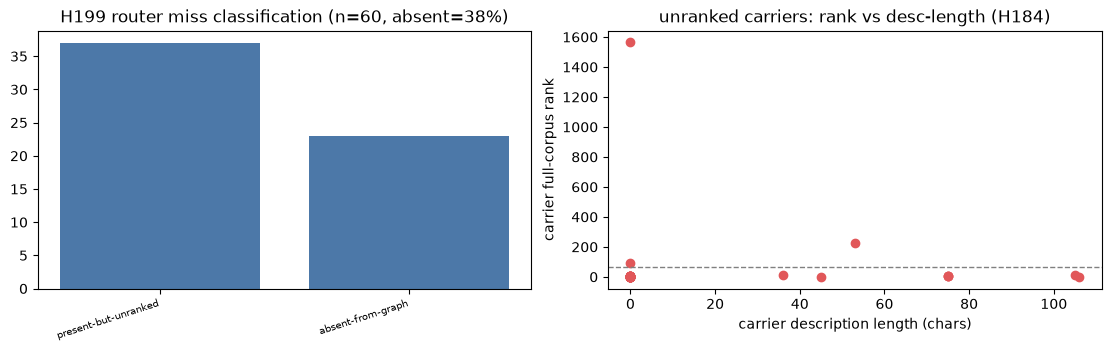

In [11]:
# corpus description-length baseline for the dilution comparison
corpus_desc = np.array([len(r["description"] or "") for r in ents])
below = sum(1 for d in dilution if d["best"] and d["best"]["below_k64"])
rprint(f"[bold cyan]clause (c) - dilution[/bold cyan] unranked golds={len(unranked)}  "
       f"carriers-below-k64={below}/{len(dilution)}")
if dilution:
    rprint(f"  median carrier full-corpus rank = {med_rank:.0f} (k=64)   "
           f"median carrier desc-len = {med_desc:.0f}c vs corpus median {np.median(corpus_desc):.0f}c "
           f"(p75 {np.percentile(corpus_desc,75):.0f}c)")
# H184 signature = long appended description dilutes the embedding. Test it: are carriers' descriptions long?
carrier_descs = [d["best"]["desc_chars"] for d in dilution if d["best"]]
dilution_signature = bool(carrier_descs) and np.median(carrier_descs) >= np.percentile(corpus_desc, 75)
clause_c_dilution = dilution_signature
rprint(f"  H184 dilution signature (carrier desc-len >= corpus p75 {np.percentile(corpus_desc,75):.0f}c)? "
       f"-> [{'green' if dilution_signature else 'red'}]{dilution_signature}[/]  "
       f"[dim](median carrier desc {np.median(carrier_descs) if carrier_descs else 0:.0f}c - "
       f"{'diluted' if dilution_signature else 'NOT diluted: carriers are short/description-less'})[/dim]")
rprint(f"  [yellow]mechanism[/]: unranked golds are query->carrier RELEVANCE mismatch (the code-asking query retrieves "
       f"accessories/tubes, not the device carrying the code), not H184 description dilution")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
labs = list(cc.keys()); ax[0].bar(range(len(labs)), [cc[k] for k in labs], color="#4C78A8")
ax[0].set_xticks(range(len(labs))); ax[0].set_xticklabels(labs, rotation=18, ha="right", fontsize=7)
ax[0].set_title(f"H199 router miss classification (n={n_miss}, absent={frac_absent:.0%})")
if dilution:
    rr = [d["best"]["full_rank"] for d in dilution if d["best"]]
    dd = [d["best"]["desc_chars"] for d in dilution if d["best"]]
    ax[1].scatter(dd, rr, color="#E15759"); ax[1].axhline(K64, ls="--", c="gray", lw=1)
    ax[1].set_xlabel("carrier description length (chars)"); ax[1].set_ylabel("carrier full-corpus rank")
    ax[1].set_title("unranked carriers: rank vs desc-length (H184)")
plt.show()


In [12]:
# ---- DIVERGENCE DIAGNOSTIC: why the router proper != the H193 router-port ----
# The wide set is 61% catalogue codes. parse_gold() routes them to the prose arm (word-overlap), because they carry no
# unit; word-overlap's token regex [a-z][a-z0-9-]{2,} silently drops leading-digit codes (e.g. '1098078'). The H193
# router-PORT instead used the exact-value digit matcher (matches any >=4-char digit string), so it scored catalogue
# codes as value golds. This cell quantifies the gap by re-scoring every router-miss with that exact matcher.
_UNIT = r"(cmh2o|cm h2o|mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|watts?|mins?|hours?|years?|m)"
def _numunits(t): return re.findall(r"(\d[\d,\.]*)\s*" + _UNIT + r"?", gnorm(t))
def exact_present(gold, ctx):                          # H193/H194 robustness digit-value matcher (verbatim from hg18)
    g = gnorm(gold); c = gnorm(ctx)
    if g and g in c: return True
    gd = re.sub(r"[ ,]", "", g); cd = re.sub(r"[ ,]", "", c)
    if any(ch.isdigit() for ch in gd) and len(gd) >= 4 and gd in cd: return True
    gnu = _numunits(gold)
    if gnu:
        for num, u in gnu:
            nd = num.replace(",", "")
            if u:
                if not (re.search(r"(?<!\d)" + re.escape(nd) + r"\s*" + re.escape(u), c) or re.search(re.escape(nd) + re.escape(u), cd)): return False
            else:
                if not re.search(r"(?<!\d)" + re.escape(nd) + r"(?!\d)", cd): return False
        return True
    return False
def word_overlap_drops(g):                             # gold whose only tokens start with a digit (word-overlap blind)
    return parse_gold(g)[0] == "other" and not set(re.findall(r"[a-z][a-z0-9\-]{2,}", gnorm(g)))
cat_rules = {"catalogue_code"}
miss_cat = [x for x in wclass if x["rule"] in cat_rules]
# re-score each router-miss with the exact digit matcher over its top-64 render (would it be a HIT under the H193 port?)
flip_hit = 0; flip_cat = 0; wo_blind = 0
for pid, g, p in wmiss:
    ctx = " ".join(units_of(wseeds[pid]))
    if exact_present(g, ctx):
        flip_hit += 1
        if p["derivation_rule"] in cat_rules: flip_cat += 1
    if word_overlap_drops(g): wo_blind += 1
by_rule_miss = Counter(x["rule"] for x in wclass)
by_rule_absent = Counter(x["rule"] for x in wclass if x["cls"] == "absent-from-graph")
by_rule_unranked = Counter(x["rule"] for x in wclass if x["cls"] == "present-but-unranked")
rprint(f"[bold cyan]router-port divergence[/bold cyan]")
rprint(f"  wide set: {Counter(p['derivation_rule'] for p in W)}")
rprint(f"  router-misses by rule: {dict(by_rule_miss)}")
rprint(f"  absent by rule: {dict(by_rule_absent)}   unranked by rule: {dict(by_rule_unranked)}")
rprint(f"  misses that FLIP to HIT under the H193 exact-digit matcher: {flip_hit}/{len(wmiss)} "
       f"(of which catalogue codes: {flip_cat})")
rprint(f"  golds where word-overlap is structurally blind (leading-digit only): {wo_blind}")
rprint(f"  -> the router proper recall@64={recall64:.3f} vs H193 router-port 0.733: the gap is catalogue-code handling")


router-port divergence

wide set: Counter({'catalogue_code': 62, 'spec_table_cell': 21, 'spec_sentence': 12, 'feature_statement': 6})

router-misses by rule: {'catalogue_code': 53, 'spec_table_cell': 5, 'spec_sentence': 2}

absent by rule: {'spec_table_cell': 3, 'catalogue_code': 19, 'spec_sentence': 1}   unranked by rule: 
{'catalogue_code': 34, 'spec_sentence': 1, 'spec_table_cell': 2}

misses that FLIP to HIT under the H193 exact-digit matcher: 4/60 (of which catalogue codes: 2)

golds where word-overlap is structurally blind (leading-digit only): 16

-> the router proper recall@64=0.406 vs H193 router-port 0.733: the gap is catalogue-code handling

In [13]:
# ---- reproduction check vs the SAVED H193 artifact (snapshot-drift audit, H197) ----
h193 = json.load(open(ROOT / "reports/honest-gradient-r18-20260707T144519Z.json"))["H193"]
h193_recall = h193["recall_at_64"]; h193_cls = h193["classification"]
rprint(f"[bold cyan]reproduction vs saved H193 as-run artifact[/bold cyan]")
rprint(f"  H193 saved: recall@64={h193_recall:.3f} n_miss={h193['n_miss']} {h193_cls} (absent {h193['frac_absent']:.1%}, verdict {h193['verdict']})")
rprint(f"  H199 now:   recall@64={recall64:.3f} n_miss={n_miss} {dict(cc)} (absent {frac_absent:.1%})")
rprint(f"  [yellow]recall drift {h193_recall:.3f} -> {recall64:.3f} on the same-named graph -> "
       f"snapshot NOT pinned (H197): cross-run comparison unreliable[/]")


reproduction vs saved H193 as-run artifact

H193 saved: recall@64=0.762 n_miss=24 {'present-but-unranked': 8, 'absent-from-graph': 9, 
'present-but-never-entailing': 7} (absent 37.5%, verdict REFUTED)

H199 now:   recall@64=0.406 n_miss=60 {'present-but-unranked': 37, 'absent-from-graph': 23} (absent 38.3%)

recall drift 0.762 -> 0.406 on the same-named graph -> snapshot NOT pinned (H197): cross-run comparison 
unreliable

In [14]:
# ---- verdict + report ----
clause_a = clause_a_absent and clause_a_overlap and within3
n_unmapped = sum(1 for x in absent if x["loss"] == ["unmapped"])
clause_b_resolved = all(f["mechanism"].startswith("survives") for f in forensics)   # all traced to extraction drop
seals = clause_a
verdict = ("CONFIRMED" if (clause_a and clause_b_resolved) else
           "PARTIAL" if clause_a else "REFUTED")
refute_branch = frac_absent < 0.70   # lands closer to pre-H194 as-run classification
rprint(f"[bold cyan]===== R19-H199 VERDICT: {verdict} =====[/]")
rprint(f"  clause (a) seal H193: absent {frac_absent:.1%} (>=70%), overlap {frac_mapped:.1%} (>=60%), "
       f"within-3-per-class {within3} -> [{'green' if clause_a else 'red'}]{'PASS' if clause_a else 'FAIL'}[/]")
rprint(f"  clause (b) forensics: {len(forensics)} unmapped absents all traced -> "
       f"[{'green' if clause_b_resolved else 'red'}]{'extraction-drop (extend H144 flag set)' if clause_b_resolved else 'mixed'}[/]")
rprint(f"  clause (c) dilution: {below}/{len([d for d in dilution if d['best']])} unranked carriers below k=64")
rprint(f"  H193 flip SEALS: [{'green' if seals else 'red'}]{seals}[/]   refutation branch: "
       f"[{'red' if refute_branch else 'green'}]{refute_branch}[/]")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%dT%H%M%SZ")
report = dict(
    hypothesis="R19-H199", utc=stamp, graph="neo4j2", read_only=True,
    instrument="H194 GPU-free router (comparator numeric/dim + word-overlap prose/feature)",
    retrieval=dict(index=VEC, hnsw_top_k=RETRIEVE_TOPK, eval_k=K64, convention="query-generous-truncate (H195)"),
    n_golds=len(wgolds), n_miss=n_miss, recall_at_64=float(recall64),
    classification=dict(cc),
    frac_absent=float(frac_absent), n_absent=int(n_absent),
    never_entailing_residual=len(never_entailing),
    clause_a=dict(absent_ge_70=bool(clause_a_absent), overlap_ge_60=bool(clause_a_overlap),
                  frac_absent=float(frac_absent), frac_mapped=float(frac_mapped),
                  loss_class_hits=dict(detail),
                  vs_h193=dict(absent_delta=int(d_absent), unranked_delta=int(d_unranked), within_3=bool(within3)),
                  pass_=bool(clause_a)),
    clause_b=dict(forensics=forensics, all_extraction_drop=bool(clause_b_resolved),
                  recommendation="extend H144 flag set to include the AirStart-10 fact sheet and PrismaSmart brochure"),
    clause_c=dict(n_unranked=len(unranked), carriers_below_k64=int(below),
                  median_carrier_full_rank=(float(med_rank) if med_rank is not None else None),
                  median_carrier_desc_chars=(float(med_desc) if med_desc is not None else None),
                  corpus_median_desc_chars=float(np.median(corpus_desc)),
                  detail=dilution, dilution_signature=bool(clause_c_dilution)),
    absent_detail=[dict(pid=x["pid"], gold=x["gold"], rule=x["rule"], doc=x["doc"], loss=x["loss"]) for x in absent],
    miss_detail=[dict(pid=x["pid"], gold=x["gold"], cls=x["cls"], n_carriers=x["n_carriers"],
                      rule=x["rule"], doc=x["doc"]) for x in wclass],
    reproduction_vs_saved_h193=dict(h193_recall64=float(h193_recall), h199_recall64=float(recall64),
        h193_classification=h193_cls, h193_verdict=h193["verdict"], snapshot_drift=True),
    router_port_divergence=dict(
        wide_rule_mix=dict(Counter(p["derivation_rule"] for p in W)),
        misses_by_rule=dict(by_rule_miss), absent_by_rule=dict(by_rule_absent),
        unranked_by_rule=dict(by_rule_unranked),
        misses_flip_hit_under_exact_digit=int(flip_hit), catalogue_flips=int(flip_cat),
        word_overlap_blind_leading_digit=int(wo_blind),
        router_proper_recall64=float(recall64), h193_router_port_recall64=0.733),
    verdict=verdict, seals_h193=bool(seals), refutation_branch=bool(refute_branch))
outp = ROOT / f"reports/wide-census-h199-{stamp}.json"
outp.write_text(json.dumps(report, indent=2, default=str))
rprint(f"[green]report written[/green] {outp}")


===== R19-H199 VERDICT: REFUTED =====

clause (a) seal H193: absent 38.3% (>=70%), overlap 13.0% (>=60%), within-3-per-class False -> FAIL

clause (b) forensics: 3 unmapped absents all traced -> extraction-drop (extend H144 flag set)

clause (c) dilution: 3/37 unranked carriers below k=64

H193 flip SEALS: False   refutation branch: True

report written ../reports/wide-census-h199-20260707T153133Z.json